In [1]:
%run "coli starting run.ipynb"

In [2]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_create(40,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(20,my_floor(true_score,-2),true_score,1)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(40,my_floor(true_score,-2),true_score,2)]).reset_index(drop=True)



score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,18.0,100.0
1,100.0,101,0,0,0,0,0,0,11.0,100.0
2,100.0,101,0,0,0,0,0,0,6.0,100.0
3,100.0,101,0,0,0,0,0,0,15.0,100.0
4,100.0,101,0,0,0,0,0,0,14.0,100.0
...,...,...,...,...,...,...,...,...,...,...
4995,500.0,591,0,0,0,0,0,2,7.0,500.0
4996,500.0,591,0,0,0,0,0,2,1.0,500.0
4997,500.0,591,0,0,0,0,0,2,14.0,500.0
4998,500.0,591,0,0,0,0,0,2,7.0,500.0


In [3]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
1806,280.0,281,0,4,6,4,2,0,4.0,200.0,80.0
4432,540.0,541,0,5,9,3,3,0,5.0,500.0,40.0
1963,380.0,291,5,15,6,11,2,2,18.0,200.0,180.0
4384,530.0,531,5,4,8,2,3,2,4.0,500.0,30.0
3361,580.0,431,5,15,12,11,4,2,17.0,400.0,180.0
...,...,...,...,...,...,...,...,...,...,...,...
1157,220.0,211,0,0,10,0,4,1,0.0,200.0,20.0
1486,320.0,241,5,8,7,6,3,2,8.0,200.0,120.0
4802,800.0,581,0,12,9,10,7,0,12.0,500.0,300.0
104,90.0,111,0,10,6,4,1,0,10.0,100.0,-10.0


<AxesSubplot:xlabel='score', ylabel='true score'>

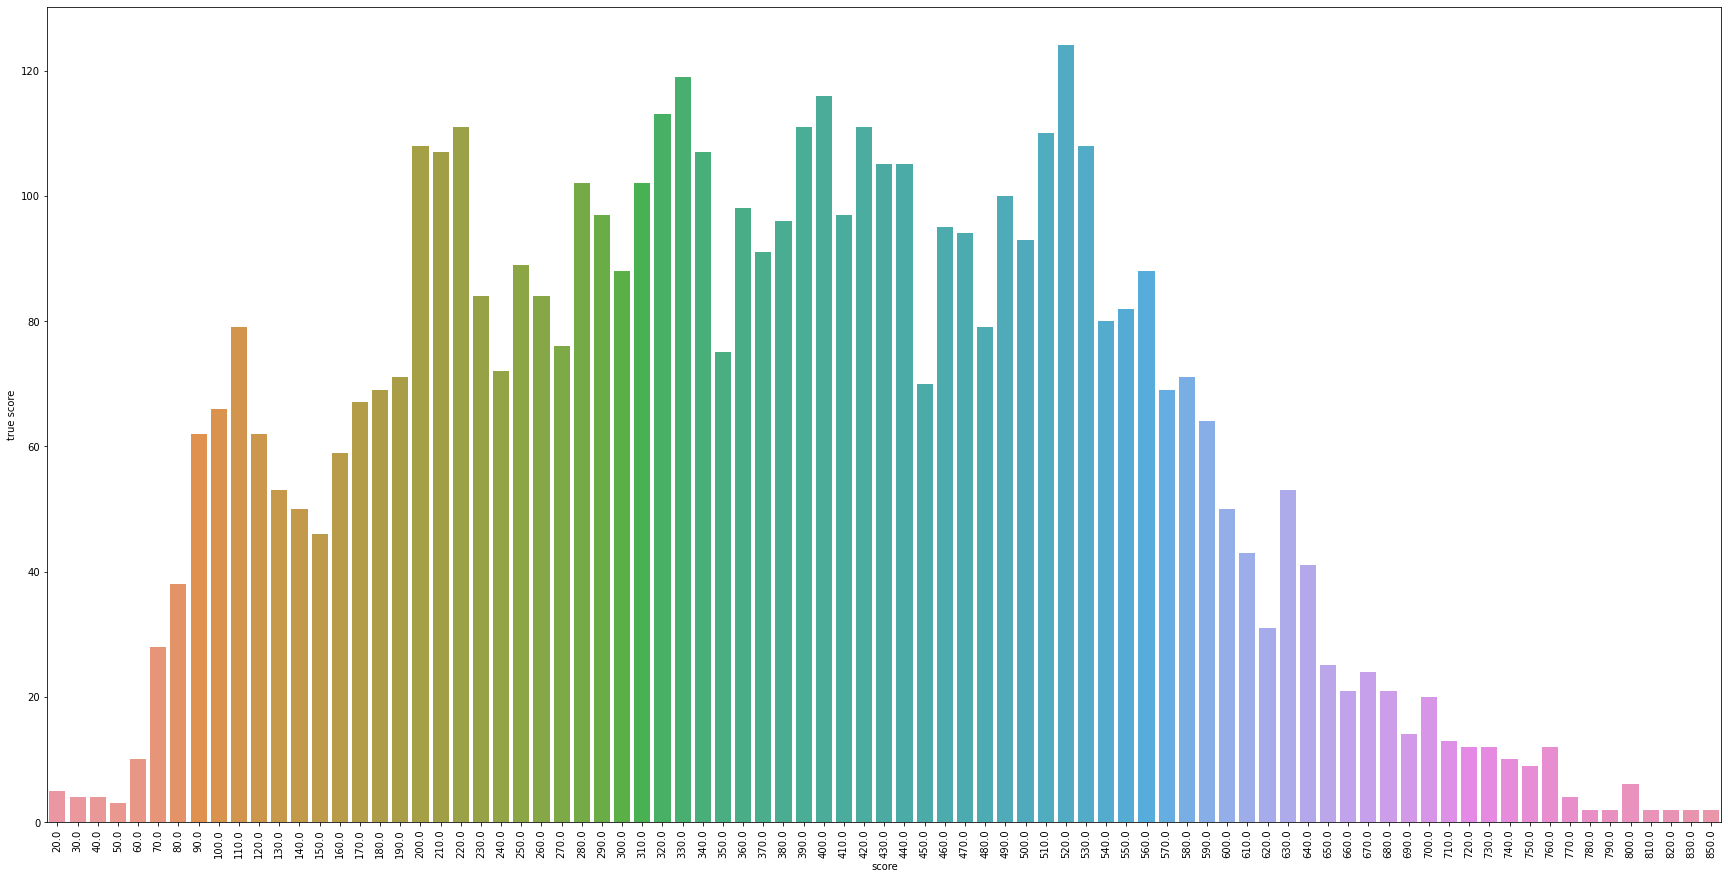

In [4]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

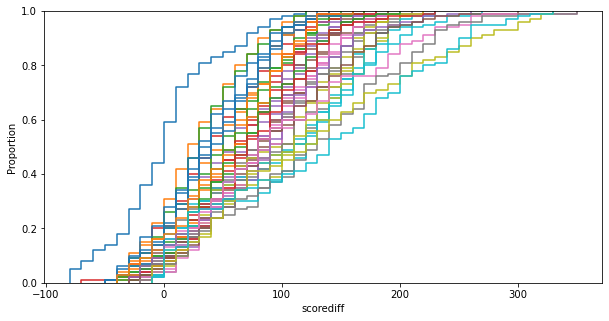

In [5]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [6]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

att count             att win            def count               \
type               0    1      2       0    1     2         0     1      2   
true score                                                                   
101             7.78  0.0   9.55    3.45  0.0  4.80      9.88  9.55  10.40   
111             8.78  0.0   8.03    4.53  0.0  4.35     10.25  6.75   9.40   
121             8.82  0.0   8.47    4.85  0.0  4.17     10.05  7.80   8.15   
131             8.85  0.0   9.57    4.72  0.0  5.10      7.92  5.70   7.62   
141             9.60  0.0   9.53    5.72  0.0  6.00      9.32  3.60   7.30   
151            10.57  0.0   8.38    6.30  0.0  5.10      9.65  4.60   6.20   
161             9.12  0.0   9.75    5.80  0.0  6.25      8.65  3.50   6.08   
171             8.68  0.0   8.88    5.58  0.0  5.80      8.68  1.50   5.47   
181             9.85  0.0   9.95    6.60  0.0  6.62      7.70  1.50   4.05   
191             9.60  0.0   8.88    7.00  0.0  6.47      6.85  0.45   3.45   
201             9.78  0.0   7.67    5.28  0.0  4.60     11.20  7.65  10.05   
211            11.75  0.0   7.50    6.40  0.0  4.45     11.88  6.90   9.00   
221             8.22  0.0   7.90    4.62  0.0  4.72      9.35  5.35   9.00   
231             9.68  0.0   7.85    5.65  0.0  5.03     11.30  6.75   7.97   
241             8.82  0.0   9.38    5.50  0.0  5.58      8.80  5.55   7.70   
251             8.40  0.0   9.90    5.30  0.0  6.35      7.83  3.35   7.53   
261            10.50  0.0   9.62    6.47  0.0  6.42      9.12  3.00   5.72   
271            10.22  0.0  11.38    6.28  0.0  7.72      7.72  2.95   6.17   
281             8.22  0.0   9.12    6.00  0.0  6.65      6.83  2.05   4.35   
291             8.53  0.0  10.12    5.90  0.0  7.25      6.03  0.55   3.48   
301             7.92  0.0   9.15    4.10  0.0  5.45     10.57  7.65  10.03   
311             8.68  0.0   9.12    4.65  0.0  5.53     12.05  8.10  10.65   
321            10.43  0.0   8.93    6.08  0.0  5.62      9.95  6.90   9.62   
331            10.53  0.0   7.70    6.17  0.0  4.92     11.05  4.75   7.88   
341             8.85  0.0   9.45    5.33  0.0  5.95      9.30  5.00   8.18   
351            10.20  0.0   9.10    6.00  0.0  5.60      9.05  3.65   6.45   
361            10.18  0.0   7.40    6.28  0.0  4.92      8.12  4.30   5.08   
371            10.55  0.0   7.72    6.62  0.0  5.20      7.62  2.05   4.60   
381            11.38  0.0   9.45    7.30  0.0  6.88      7.80  1.85   4.83   
391             8.28  0.0   9.03    6.05  0.0  6.58      7.03  0.70   2.77   
401             8.12  0.0  10.28    4.12  0.0  5.83      9.38  7.10  10.35   
411            10.03  0.0   8.00    5.65  0.0  4.92     11.72  7.60  10.25   
421            10.12  0.0   8.82    5.55  0.0  5.47      9.97  5.55  10.93   
431             9.50  0.0   9.18    5.58  0.0  6.10     10.18  5.55   9.50   
441            11.45  0.0   7.55    6.75  0.0  4.83     10.35  6.15   7.17   
451             9.45  0.0   8.35    5.97  0.0  5.22      9.12  5.05   6.25   
461             9.68  0.0   9.15    6.12  0.0  5.90      7.92  2.65   6.72   
471             9.53  0.0   9.43    6.38  0.0  6.28      8.12  2.50   5.12   
481             9.85  0.0   9.38    6.62  0.0  6.67      7.17  1.50   5.08   
491            10.45  0.0  10.75    7.42  0.0  8.05      7.28  0.80   4.90   
501             9.28  0.0   8.45    4.67  0.0  4.92     10.88  8.30  11.10   
511             8.53  0.0   7.90    4.95  0.0  4.88     12.38  7.35   9.82   
521             9.85  0.0   9.22    5.50  0.0  5.92     11.03  7.40  10.70   
531             9.00  0.0   9.90    5.33  0.0  6.17     10.32  6.15  10.60   
541            10.45  0.0   8.45    7.03  0.0  5.75     12.50  4.85   7.47   
551             9.10  0.0   9.05    5.88  0.0  6.20      9.95  4.65   7.33   
561             7.95  0.0   8.82    5.65  0.0  6.30      8.40  3.00   7.30   
571             9.88  0.0  10.10    7.08  0.0  7.90      7.72  2.60   6.00   
581             9.70  0.0   9.82 

In [7]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399]

att count            att win            def count               \
type               0    1     2       0    1     2         0     1      2   
true score                                                                  
301             7.92  0.0  9.15    4.10  0.0  5.45     10.57  7.65  10.03   
311             8.68  0.0  9.12    4.65  0.0  5.53     12.05  8.10  10.65   
321            10.43  0.0  8.93    6.08  0.0  5.62      9.95  6.90   9.62   
331            10.53  0.0  7.70    6.17  0.0  4.92     11.05  4.75   7.88   
341             8.85  0.0  9.45    5.33  0.0  5.95      9.30  5.00   8.18   
351            10.20  0.0  9.10    6.00  0.0  5.60      9.05  3.65   6.45   
361            10.18  0.0  7.40    6.28  0.0  4.92      8.12  4.30   5.08   
371            10.55  0.0  7.72    6.62  0.0  5.20      7.62  2.05   4.60   
381            11.38  0.0  9.45    7.30  0.0  6.88      7.80  1.85   4.83   
391             8.28  0.0  9.03    6.05  0.0  6.58      7.03  0.70   2.77   

           def win             int_score               play_time              \
type             0     1     2         0      1      2         0    1      2   
true score                                                                     
301           3.30  2.60  2.83     300.0  300.0  300.0      7.92  0.0   9.57   
311           4.00  3.55  3.33     300.0  300.0  300.0      8.68  0.0   9.78   
321           2.73  3.10  3.38     300.0  300.0  300.0     10.43  0.0   9.43   
331           3.62  2.45  2.52     300.0  300.0  300.0     10.53  0.0   8.18   
341           3.20  2.60  3.10     300.0  300.0  300.0      8.85  0.0  10.05   
351           3.12  2.05  2.67     300.0  300.0  300.0     10.20  0.0   9.72   
361           3.15  2.70  2.12     300.0  300.0  300.0     10.18  0.0   7.90   
371           2.73  1.20  2.23     300.0  300.0  300.0     10.55  0.0   8.12   
381           2.90  1.35  2.35     300.0  300.0  300.0     11.38  0.0   9.93   
391           2.85  0.65  1.32     300.0  300.0  300.0      8.28  0.0   9.43   

             score                scorediff               skiped time        
type             0      1       2         0     1       2           0  1  2  
true score                                                                   
301         337.00  301.5  356.50     37.00   1.5   56.50           0  0  5  
311         352.25  325.5  367.75     52.25  25.5   67.75           0  0  5  
321         360.25  324.0  384.50     60.25  24.0   84.50           0  0  5  
331         378.25  326.0  367.75     78.25  26.0   67.75           0  0  5  
341         374.25  328.0  395.25     74.25  28.0   95.25           0  0  5  
351         381.25  325.0  392.75     81.25  25.0   92.75           0  0  5  
361         399.75  338.0  386.75     99.75  38.0   86.75           0  0  5  
371         398.75  315.5  399.50     98.75  15.5   99.50           0  0  5  
381         414.25  322.0  434.00    114.25  22.0  134.00           0  0  5  
391         414.00  312.5  419.00    114.00  12.5  119.00           0  0  5

In [8]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[400:499][['att count','def count','scorediff']]

att count             def count              scorediff        \
type               0    1      2         0     1      2         0     1   
true score                                                                
401             8.12  0.0  10.28      9.38  7.10  10.35     28.25   8.5   
411            10.03  0.0   8.00     11.72  7.60  10.25     62.25  20.0   
421            10.12  0.0   8.82      9.97  5.55  10.93     57.75  12.0   
431             9.50  0.0   9.18     10.18  5.55   9.50     71.00  16.5   
441            11.45  0.0   7.55     10.35  6.15   7.17     93.25  31.5   
451             9.45  0.0   8.35      9.12  5.05   6.25     84.25  29.0   
461             9.68  0.0   9.15      7.92  2.65   6.72     91.00  14.0   
471             9.53  0.0   9.43      8.12  2.50   5.12    107.00  26.0   
481             9.85  0.0   9.38      7.17  1.50   5.08    102.75  16.5   
491            10.45  0.0  10.75      7.28  0.80   4.90    116.75  11.5   

                    
type             2  
true score          
401          64.50  
411          68.00  
421          81.50  
431          84.00  
441          84.50  
451          97.75  
461         113.50  
471         112.50  
481         122.50  
491         154.00